In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import (
    clean_column_names,
    clean_total_charges,
    encode_Yes_No_features,
    prepare_target,
    drop_unused_columns,
    encode_binary_features,
    encode_categorical_features
)

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

#DATA_PATH = "data/raw/Telco-Customer-Churn.csv"

#df = pd.read_csv(DATA_PATH)

df.head()
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

(7043, 21)

In [3]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

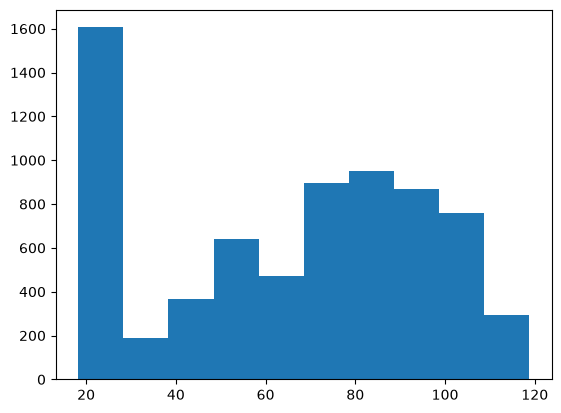

In [4]:
plt.hist(df["MonthlyCharges"])
plt.show()

In [4]:
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [6]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


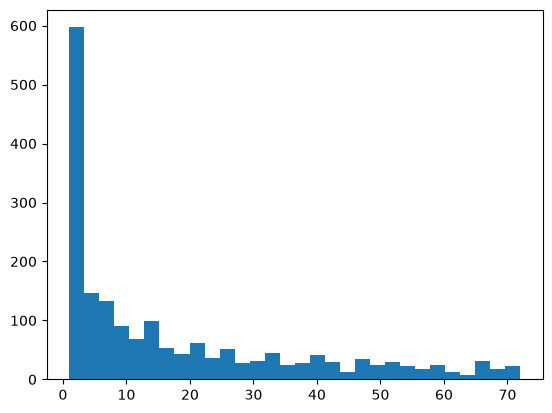

In [7]:
plt.hist(df[df["Churn"]=="Yes"]["tenure"], bins=30)
plt.show()

In [8]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [9]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [10]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [11]:
pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


In [5]:
df = drop_unused_columns(df)

In [6]:
df = clean_column_names(df)
df = clean_total_charges(df)
df = prepare_target(df)
df = encode_binary_features(df)
df = encode_categorical_features(df)

In [14]:
df.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No inter

In [15]:
df.select_dtypes(include="object").columns

Index([], dtype='str')

In [7]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [19]:
X.shape
y.shape

(7043,)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled.mean(axis=0)
X_train_scaled.std(axis=0)

array([ 1.13505229e-16,  7.44089837e-17, -7.03101837e-17,  2.90068919e-17,
       -1.00893537e-17, -2.67998458e-18,  3.94115380e-17, -2.40252735e-16,
        2.52233843e-17,  2.67998458e-18, -2.52233843e-18, -4.28797533e-17,
       -7.72466144e-17, -7.72466144e-17,  2.14398767e-17, -7.72466144e-17,
        2.77457227e-17, -7.72466144e-17,  3.78350765e-18, -7.72466144e-17,
       -2.01787074e-17, -7.72466144e-17,  8.82818451e-18, -7.72466144e-17,
        5.92749531e-17, -4.54020917e-17,  4.76091379e-17, -4.28797533e-17,
       -3.27903996e-17, -2.01787074e-17])

In [12]:
from sklearn.linear_model import LogisticRegression

In [13]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [14]:
y_pred = model.predict(X_test_scaled)

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
accuracy_score(
    y_test,
    y_pred
)

0.8069552874378992

In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [18]:
from sklearn.metrics import confusion_matrix

confusion_matrix(
    y_test,
    y_pred
)

array([[925, 110],
       [162, 212]])

In [19]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(
    X_test_scaled
)[:,1]

roc_auc_score(
    y_test,
    y_prob
)

0.841778397788628

In [20]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
11,InternetService_Fiber optic,0.776154
8,TotalCharges,0.514285
24,StreamingMovies_Yes,0.257227
22,StreamingTV_Yes,0.257144
10,MultipleLines_Yes,0.216167
6,PaperlessBilling,0.182034
28,PaymentMethod_Electronic check,0.181103
1,SeniorCitizen,0.053073
18,DeviceProtection_Yes,0.053048
29,PaymentMethod_Mailed check,0.032262


In [21]:
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

coef_df= coef_df.sort_values(
    by="AbsCoefficient",
    ascending=False
)

coef_df

,Feature,Coefficient,AbsCoefficient
4,tenure,-1.236528,1.236528
7,MonthlyCharges,-0.920153,0.920153
11,InternetService_Fiber optic,0.776154,0.776154
26,Contract_Two year,-0.586859,0.586859
8,TotalCharges,0.514285,0.514285
25,Contract_One year,-0.285509,0.285509
24,StreamingMovies_Yes,0.257227,0.257227
22,StreamingTV_Yes,0.257144,0.257144
10,MultipleLines_Yes,0.216167,0.216167
6,PaperlessBilling,0.182034,0.182034


In [22]:
corr = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
].corr()

corr

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


In [52]:
df[df["tenure"]==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
488,0,0,1,1,0,0,1,52.55,0.0,0,...,True,False,True,False,False,False,True,False,False,False
753,1,0,0,1,0,1,0,20.25,0.0,0,...,False,True,False,True,False,False,True,False,False,True
936,0,0,1,1,0,1,0,80.85,0.0,0,...,False,False,True,False,True,False,True,False,False,True
1082,1,0,1,1,0,1,0,25.75,0.0,0,...,False,True,False,True,False,False,True,False,False,True
1340,0,0,1,1,0,0,0,56.05,0.0,0,...,True,False,True,False,False,False,True,True,False,False
3331,1,0,1,1,0,1,0,19.85,0.0,0,...,False,True,False,True,False,False,True,False,False,True
3826,1,0,1,1,0,1,0,25.35,0.0,0,...,False,True,False,True,False,False,True,False,False,True
4380,0,0,1,1,0,1,0,20.00,0.0,0,...,False,True,False,True,False,False,True,False,False,True
5218,1,0,1,1,0,1,1,19.70,0.0,0,...,False,True,False,True,False,True,False,False,False,True
6670,0,0,1,1,0,1,0,73.35,0.0,0,...,True,False,True,False,False,False,True,False,False,True


In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [34]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [35]:
y_pred_rf = rf_model.predict(X_test)

In [53]:
accuracy_score(
    y_test,
    y_pred_rf
)

0.7494677075940384

In [58]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [44]:
confusion_matrix(
    y_test,
    y_pred_rf
)

array([[844, 191],
       [124, 250]])

In [59]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
#Trying to lower the decision treshold
#y_prob_rf = rf_model.predict_proba(X_test)[:,1]
#y_pred_rf = (y_prob > 0.5).astype(int)

roc_auc_score(
    y_test,
    y_prob_rf
)

0.8445865302642797

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,tenure,0.199508
8,TotalCharges,0.152385
7,MonthlyCharges,0.103824
11,InternetService_Fiber optic,0.081524
26,Contract_Two year,0.068057
28,PaymentMethod_Electronic check,0.065966
25,Contract_One year,0.033944
14,OnlineSecurity_Yes,0.033499
20,TechSupport_Yes,0.026516
6,PaperlessBilling,0.022357


In [33]:
rf_model=RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)